# Security selection

In [1]:
import pandas as pd
import numpy as np

In [2]:
from src.selection import FundamentalScoreConfig

from src.optimization import (
    MinimumVarianceConfig,
    MaximumOmegaConfig,
    MinimumSemivarianceConfig,
    PostModernOptimizationConfig,
    OptimizationConfig
)


from src.backtesting import (
    BacktestConfig,
    RebalanceConfig
)

In [3]:
from src.selection import FundamentalSelector

from src.research import AssetsResearch

from src.portfolio import Portfolio
from src.portfolio import PortfolioPerformanceAnalysis

from src.optimization import MeanVarianceOptimizer
from src.optimization import PostModernOptimizer

from src.backtesting import (
    DynamicBacktestEngine, 
    PostModernStrategy,
    MeanVarianceStrategy
)

In [58]:
start_date = "2016-01-01"
end_date = "2026-05-02"

In [5]:
tickets = [
'LNG',
'MATX',
'DAL',
'PARR',
'MTDR',
'OVV',
'DEC',
'CNX',
'DVN',
'APA',
'SGU',
'MNR',
'VG'
]

selector = FundamentalSelector(strategy="growth")

ranking = selector.rank(tickers=tickets)

history = selector.rank_over_time(
    tickers=tickets,
    frequency="annual",
    trailing_periods=4
)

report = selector.selection_report(ranking=ranking, top_k=5)

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/quote.py:702: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  start = pd.Timestamp.utcnow().floor("D") - datetime.timedelta(days=365 // 2)
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/quote.py:704: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/fundamentals.py:120: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/fundamentals.py:120: Pandas4Warning: Timestamp.utcnow is deprecated and will be re

In [6]:
report["selected"]

,ticker,fundamental_score,score_coverage,strategy,sector,industry
0,LNG,73.410256,1.00,growth,Energy,Oil & Gas Midstream
1,VG,65.044872,1.00,growth,Energy,Oil & Gas Midstream
2,CNX,63.326923,1.00,growth,Energy,Oil & Gas E&P
3,OVV,62.006410,1.00,growth,Energy,Oil & Gas E&P
4,MNR,61.217949,0.95,growth,Energy,Oil & Gas E&P


In [7]:
report["metric_snapshot"]

,ticker,revenue__period_change,revenue__yoy_change,eps__period_change,eps__yoy_change,net_income__period_change,free_cash_flow__period_change,revenue__historical_avg_change,eps__historical_avg_change,free_cash_flow__historical_avg_change,gross_margin__level,operating_margin__level,roe__level,return_on_invested_capital__level,operating_margin__historical_avg_change,peg_ratio__level,trailing_pe__level,debt_to_equity__level,interest_coverage__level
0,LNG,0.227201,0.228584,1.248421,1.466513,1.194471,0.776423,0.065959,0.977844,0.961404,0.477123,0.462054,0.673405,0.234192,0.074494,9.460000,11.187242,3.223626,9.736287
1,VG,0.335236,1.916667,1.562500,0.138933,1.187037,-0.072998,0.344809,0.263843,0.141287,0.501707,0.349844,0.399970,0.099636,-0.114628,1.780000,13.836956,5.175886,3.312930
2,CNX,0.190810,0.283264,0.703125,2.626866,-0.028951,-0.224894,0.091979,0.549573,0.058432,0.472348,0.454397,0.145990,0.110600,0.217475,1.930000,5.050667,0.600609,5.706792
3,OVV,0.039206,-0.018739,5.553181,17.211259,5.391892,0.824627,-0.001987,1.040650,0.209556,0.560844,0.128648,0.110942,0.025579,0.053574,1.850000,12.730124,0.573828,3.047872
4,MNR,0.421853,0.649519,5.587778,-0.400343,7.060330,-0.390779,0.151014,1.954710,-0.215623,0.333520,0.183091,0.143747,NaN,-0.001471,1.364763,12.642201,0.584907,2.979867


In [8]:
report["score_weights"]

,metric,signal,signal_column,weight,higher_is_better,normalizer,change_method,category,component_column
0,revenue,period_change,revenue__period_change,0.09,True,percentile_rank,relative,growth,revenue__period_change_score
1,revenue,yoy_change,revenue__yoy_change,0.09,True,percentile_rank,relative,growth,revenue__yoy_change_score
2,eps,period_change,eps__period_change,0.09,True,percentile_rank,relative,growth,eps__period_change_score
3,eps,yoy_change,eps__yoy_change,0.09,True,percentile_rank,relative,growth,eps__yoy_change_score
4,net_income,period_change,net_income__period_change,0.05,True,percentile_rank,relative,growth,net_income__period_change_score
5,free_cash_flow,period_change,free_cash_flow__period_change,0.05,True,percentile_rank,relative,cash_flow,free_cash_flow__period_change_score
6,revenue,historical_avg_change,revenue__historical_avg_change,0.07,True,percentile_rank,relative,growth,revenue__historical_avg_change_score
7,eps,historical_avg_change,eps__historical_avg_change,0.07,True,percentile_rank,relative,growth,eps__historical_avg_change_score
8,free_cash_flow,historical_avg_change,free_cash_flow__historical_avg_change,0.05,True,percentile_rank,relative,cash_flow,free_cash_flow__historical_avg_change_score
9,gross_margin,level,gross_margin__level,0.04,True,percentile_rank,difference,profitability,gross_margin__level_score


In [9]:
report["score_components"]

,ticker,revenue__period_change_score,revenue__yoy_change_score,eps__period_change_score,eps__yoy_change_score,net_income__period_change_score,free_cash_flow__period_change_score,revenue__historical_avg_change_score,eps__historical_avg_change_score,free_cash_flow__historical_avg_change_score,gross_margin__level_score,operating_margin__level_score,roe__level_score,return_on_invested_capital__level_score,operating_margin__historical_avg_change_score,peg_ratio__level_score,trailing_pe__level_score,debt_to_equity__level_score,interest_coverage__level_score
0,LNG,0.750000,0.750000,0.666667,0.750000,0.750000,0.916667,0.666667,0.666667,0.750000,0.846154,1.000000,1.000000,1.000000,0.916667,0.076923,0.461538,0.153846,0.769231
1,VG,0.833333,1.000000,0.750000,0.583333,0.666667,0.750000,1.000000,0.416667,0.583333,0.923077,0.846154,0.923077,0.166667,0.083333,0.461538,0.076923,0.076923,0.307692
2,CNX,0.666667,0.833333,0.583333,0.916667,0.333333,0.583333,0.750000,0.500000,0.333333,0.769231,0.923077,0.307692,0.250000,1.000000,0.307692,0.923077,0.692308,0.384615
3,OVV,0.583333,0.416667,0.916667,1.000000,0.916667,1.000000,0.416667,0.750000,0.666667,1.000000,0.307692,0.076923,0.083333,0.833333,0.384615,0.153846,0.846154,0.230769
4,MNR,0.916667,0.916667,1.000000,0.166667,1.000000,0.500000,0.833333,1.000000,0.166667,0.538462,0.461538,0.230769,0.000000,0.416667,0.615385,0.230769,0.769231,0.153846


In [10]:
history.iloc[history["ticker"] == "DEC", :].dropna()

,ticker,frequency,period,current_price,market_cap,enterprise_value,shares_outstanding,eps,eps_recurring,eps_basic,...,free_cash_flow__period_change,free_cash_flow__period_change_score,revenue__historical_avg_change,revenue__historical_avg_change_score,eps__historical_avg_change,eps__historical_avg_change_score,free_cash_flow__historical_avg_change,free_cash_flow__historical_avg_change_score,operating_margin__historical_avg_change,operating_margin__historical_avg_change_score
19,DEC,annual,2023-12-31,16.450001,7.823082e+08,2.086304e+09,47556726.0,15.76,15.76,15.87,...,-0.280113,0.666667,-0.547626,0.166667,2.063428,0.75,-0.280113,0.666667,1.654488,1.000000
38,DEC,annual,2024-12-31,16.450001,8.331900e+08,2.576731e+09,50649844.0,-2.17,-2.17,-2.17,...,-0.223912,0.416667,-0.316094,0.166667,0.462869,0.75,-0.252013,0.583333,0.112119,0.916667


## Best EPS research

In [11]:
tickets = ['MUSA',
'LNG',
'MATX',
'MPC',
'PSX',
'EOG',
'TRGP',
'L',
'DAL',
'VLO',
'ATO',
'PARR',
'XOM',
'CVX',
'MTDR',
'CPK',
'NFG',
'FANG',
'OKE',
'CQP']

In [12]:
# @dataclass(frozen=True)
# class ValueScoreConfig(FundamentalScoreConfig):
#     """Default Graham/Buffett-inspired value score."""

#     name: str = "value"
#     metric_weights: Mapping[str, float] = field(
#         default_factory=lambda: {
#             "trailing_pe": 0.25,
#             "price_to_book": 0.20,
#             "debt_to_equity": 0.15,
#             "roe": 0.15,
#             "profit_margin": 0.10,
#             "free_cash_flow_margin": 0.10,
#             "current_ratio": 0.05,
#         }
#     )
#     higher_is_better: Mapping[str, bool] = field(
#         default_factory=lambda: {
#             "trailing_pe": False,
#             "price_to_book": False,
#             "debt_to_equity": False,
#             "roe": True,
#             "profit_margin": True,
#             "free_cash_flow_margin": True,
#             "current_ratio": True,
#         }
#     )

FundamentalScoreConfig(
    
    name="value_adjust",
    
    metric_weights={
        #Metricas de precio
        'trailing_pe' : 0.2,
        'price_to_book': 0.05,
        
        #Metricas de apalancamiento
        'debt_to_equity' : 0.2,
        
        #Metricas de rentabilidad
        'roe' : 0.15,
        'profit_margin' : 0.1,
        'operating_margin' : 0.1,
        
        #Metricas de crecimiento
        'revenue_growth' : 0.1
    },
    
    higher_is_better={
        'trailing_pe' : False
    }
)


selector = FundamentalSelector(strategy="growth")
ranking_grow = selector.rank(tickers=tickets)


selector.set_strategy("value")
ranking_value = selector.rank(tickers=tickets)

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/quote.py:702: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  start = pd.Timestamp.utcnow().floor("D") - datetime.timedelta(days=365 // 2)
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/quote.py:704: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/fundamentals.py:120: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/fundamentals.py:120: Pandas4Warning: Timestamp.utcnow is deprecated and will be re

In [13]:
report_grow = selector.selection_report(ranking=ranking_grow, top_k=5)
report_grow["selected"]

,ticker,fundamental_score,score_coverage,strategy,sector,industry
0,LNG,81.928947,1.00,growth,Energy,Oil & Gas Midstream
1,CQP,69.897368,0.95,growth,Energy,Oil & Gas Midstream
2,NFG,69.586842,1.00,growth,Energy,Oil & Gas Integrated
3,ATO,62.465789,1.00,growth,Utilities,Utilities - Regulated Gas
4,CPK,61.226316,1.00,growth,Utilities,Utilities - Regulated Gas


In [14]:
report_value = selector.selection_report(ranking=ranking_value, top_k = 5)
report_value["selected"]

,ticker,fundamental_score,score_coverage,strategy,sector,industry
0,LNG,68.631579,1.00,value,Energy,Oil & Gas Midstream
1,NFG,67.568421,1.00,value,Energy,Oil & Gas Integrated
2,PARR,64.044737,0.96,value,Energy,Oil & Gas Refining & Marketing
3,EOG,60.586842,1.00,value,Energy,Oil & Gas E&P
4,DAL,60.307895,1.00,value,Industrials,Airlines


In [15]:
ranking = selector.rank(tickers=tickets)

history = selector.rank_over_time(
    tickers=tickets,
    frequency="annual",
    trailing_periods=4
)

report = selector.selection_report(ranking=ranking, top_k=5)

## Upstream Energy

In [16]:
tickers = [
    'TPL', 'NRP', 'AM', 'REI', 'PROP', 'DTI', 'UNTC', 'AROC', 'CNX', 'GLNG',
    'MGY', 'EXE', 'REPX', 'INR', 'NFG', 'SD', 'MTDR', 'MIND', 'LPG', 'EQT',
    'INSW', 'KGS', 'WMB', 'GPOR', 'EOG', 'TDY', 'USAC', 'NCSM', 'DHT', 'APA',
    'NGS', 'ITRI', 'BORR', 'CRC', 'ITT', 'FANG', 'RRC', 'FLOC', 'WHD', 'OXY',
    'CTRA', 'PR', 'KLNG', 'SEI', 'BKV', 'NOG', 'CAT', 'EE', 'SM', 'TDW',
    'WFRD', 'HMH', 'GEOS', 'ACTG', 'OVV', 'MNR', 'FET', 'TK', 'BH', 'TNK',
    'WBI', 'PNRG', 'DEC', 'TTI', 'VAL', 'INVX', 'DVN', 'COP', 'AMPY', 'BKR',
    'ASC', 'EGY', 'CRGY', 'CRK', 'AR', 'FTI', 'XOM', 'MUR', 'ARLP', 'VTOL',
    'NOV', 'GEL', 'HPK', 'NGL', 'OII', 'GEV', 'NE', 'NBR', 'BOOM', 'CLB',
    'CHRD', 'ICDIQ', 'SLB', 'HNRG', 'HAL', 'HP', 'CVX', 'VATE', 'GFR', 'RES',
    'WTTR', 'NC', 'OIS', 'XPRO', 'MMLP', 'HLX', 'ET', 'SDRL', 'AESI', 'FIP',
    'NESR', 'TXO', 'PUMP', 'DWSN', 'MTZ', 'GTE', 'HCC', 'LBRT', 'RNGR', 'UUUU',
    'SXC', 'KLXE', 'WTI', 'PTEN', 'ACDC', 'TALO', 'BTU', 'METC', 'AMR', 'CNR',
    'SMHI', 'ENSV', 'KOS', 'EP', 'TUSK', 'VTDRF', 'UEC'
]

In [17]:
selector = FundamentalSelector(strategy="growth")
ranking_grow = selector.rank(tickers=tickets)

selector.set_strategy("value")
ranking_value = selector.rank(tickers=tickets)

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/quote.py:702: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  start = pd.Timestamp.utcnow().floor("D") - datetime.timedelta(days=365 // 2)
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/quote.py:704: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/fundamentals.py:120: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/fundamentals.py:120: Pandas4Warning: Timestamp.utcnow is deprecated and will be re

In [18]:
report_grow = selector.selection_report(ranking=ranking_grow, top_k=5)
report_grow["selected"]

,ticker,fundamental_score,score_coverage,strategy,sector,industry
0,LNG,81.928947,1.00,growth,Energy,Oil & Gas Midstream
1,CQP,69.897368,0.95,growth,Energy,Oil & Gas Midstream
2,NFG,69.586842,1.00,growth,Energy,Oil & Gas Integrated
3,ATO,62.465789,1.00,growth,Utilities,Utilities - Regulated Gas
4,CPK,61.226316,1.00,growth,Utilities,Utilities - Regulated Gas


In [19]:
report_value = selector.selection_report(ranking=ranking_value, top_k = 5)
report_value["selected"]

,ticker,fundamental_score,score_coverage,strategy,sector,industry
0,LNG,68.631579,1.00,value,Energy,Oil & Gas Midstream
1,NFG,67.568421,1.00,value,Energy,Oil & Gas Integrated
2,PARR,64.044737,0.96,value,Energy,Oil & Gas Refining & Marketing
3,EOG,60.586842,1.00,value,Energy,Oil & Gas E&P
4,DAL,60.307895,1.00,value,Industrials,Airlines


# Optimization

In [20]:
tickets_upstrem_value = report_value["selected"].loc[:, ["ticker"]]
tickets_upstrem_growt = report_grow["selected"].loc[:, ["ticker"]]

tickets_upstrem_value

,ticker
0,LNG
1,NFG
2,PARR
3,EOG
4,DAL


In [60]:
assets_upstream_value = AssetsResearch(
    tickers=tickets_upstrem_value["ticker"].values.tolist(), 
    start=start_date,
    end=end_date
    )

prices_upstream_value = assets_upstream_value.get_prices()

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


In [61]:
start_window_opt = "2017-01-01"
end_window_opt = "2026-05-02"

In [62]:
prices_upstream_value = prices_upstream_value.loc[start_window_opt:]

n_assets_value = len(prices_upstream_value.columns)

initial_weight = np.ones(n_assets_value) / n_assets_value

portfolio_upstream_value = Portfolio(
    prices=prices_upstream_value,
    weights=initial_weight, 
)

In [63]:
portfolio_upstream_value_opt = PostModernOptimizer(portfolio=portfolio_upstream_value)

In [64]:
min_semivar_weight = portfolio_upstream_value_opt.optimize_minimum_semivariance().weights_by_ticker.round(decimals= 4)
min_semivar_weight

DAL     0.1092
EOG     0.0000
LNG     0.2332
NFG     0.6487
PARR    0.0089
Name: weight, dtype: float64

In [65]:
portfolio_upstream_value_opt.optimize_maximum_omega().weights_by_ticker.round(decimals=4)

DAL     0.0
EOG     0.0
LNG     0.0
NFG     0.0
PARR    1.0
Name: weight, dtype: float64

In [66]:
portfolio_upstream_value_semivar_a = PortfolioPerformanceAnalysis(
    portfolio=Portfolio(
        prices=prices_upstream_value,
        weights=min_semivar_weight, 
    )
)

portfolio_upstream_value_semivar_a.sortino_ratio()

1.0333402383099817

In [67]:
portfolio_upstream_value_semivar_a.summary()

,value
Rendimiento esperado,0.144832
Rendimiento realizado,2.039528
Volatilidad,0.224131
Ratio de sharpe,0.646194
Downside risk,0.140159
Upside risk,0.135021
Omega,0.963342
Beta,NaN
Alpha de Jensen,NaN
Ratio de Treynor,NaN


# Backtesting

In [97]:
window_back_test = "2021-01-01"

RebalanceConfigBack = RebalanceConfig(
    lookback_months=12,
    rebalance_months=1,
    expanding_window=False,
    transaction_cost=0.005
)

In [ ]:
max_allocation = 0.4
n_activos = 5

strategies = [
    
    PostModernStrategy(
        objective="minimum_semivariance",
        config=MinimumSemivarianceConfig(
            threshold=0.01,
            minimum_return=0.20,
            bounds=[(0, max_allocation)] * n_activos,
        ),
    ),
    
    MeanVarianceStrategy(
        objective="minimum_variance",
        config=MinimumVarianceConfig(
            risk_free_rate=0.045,
            minimum_return=0.20,
            bounds=[(0, max_allocation)] * n_activos,
        ),
    ),
    
    MeanVarianceStrategy(
        objective="maximum_sharpe",
        config=OptimizationConfig(
            risk_free_rate=0.045,
            bounds=[(0, max_allocation)] * n_activos,
        ),
    ),
]

## Upstream

### Value

In [ ]:
tickers_upstrem_value = tickets_upstrem_value["ticker"].values.tolist()

BacktestConfigValue = BacktestConfig(
    tickers = tickers_upstrem_value,
    initial_capital = 1_000_000,
    optimization_start = start_window_opt,
    backtest_start = window_back_test,
    end = end_window_opt,
    risk_free_rate=0.045
)

In [ ]:
DynamicBacktestEngineValue = DynamicBacktestEngine(
    config=BacktestConfigValue,
    rebalance_config=RebalanceConfigBack
)

results = DynamicBacktestEngineValue.run(
    strategies=strategies,
    prices=prices_upstream_value,
)

In [ ]:
results.evolution.plot()

In [91]:
# Rebalanceo mensual, ventana cada 6 meses
results.metrics

,Min Semivar,Min Var,Max Sharpe
Rendimiento esperado,0.241338,0.238825,0.261536
Rendimiento realizado,2.177269,2.135537,2.404134
Volatilidad,0.216137,0.216020,0.247004
Ratio de sharpe,0.908398,0.897254,0.876649
Downside risk,0.126577,0.126436,0.146806
Upside risk,0.132512,0.131917,0.148767
Omega,1.046892,1.043348,1.013355
Beta,NaN,NaN,NaN
Alpha de Jensen,NaN,NaN,NaN
Ratio de Treynor,NaN,NaN,NaN


In [92]:
results.evolution.tail(1)

,Min Semivar,Min Var,Max Sharpe
2026-05-01,3.177269e+06,3.135537e+06,3.404134e+06


In [93]:
results.transaction_costs.sum()

Min Semivar    127964.376322
Min Var        127037.126959
Max Sharpe     156745.648986
dtype: float64

In [94]:
results.turnover.round(decimals=4)

,Min Semivar,Min Var,Max Sharpe
2021-01-04,0.0000,0.0000,0.0000
2021-02-04,0.0000,0.0000,0.0000
2021-03-04,0.6673,0.7567,0.0000
2021-04-05,0.1327,0.0772,0.4311
2021-05-04,0.0735,0.0446,0.2063
...,...,...,...
2025-12-04,0.0516,0.0786,0.2747
2026-01-05,0.0493,0.0789,0.1253
2026-02-04,0.1715,0.1932,0.0791
2026-03-04,0.1669,0.2823,0.1426


In [95]:
# ['Min Semivar', 'Min Var', 'Max Sharpe']
name_strategy = "Min Semivar"

results.weights_history.loc[
    results.weights_history["strategy"] == name_strategy, :
].round(decimals=4).iloc[:, 1:] * 1_000_000

,LNG,NFG,PARR,EOG,DAL
date,,,,,
2021-01-04,400000.0,200000.0,400000.0,0.0,0.0
2021-02-04,400000.0,200000.0,400000.0,0.0,0.0
2021-03-04,400000.0,400000.0,66400.0,35400.0,98200.0
2021-04-05,400000.0,400000.0,0.0,44400.0,155600.0
2021-05-04,400000.0,400000.0,0.0,7600.0,192400.0
...,...,...,...,...,...
2025-12-04,163600.0,400000.0,49700.0,246200.0,140500.0
2026-01-05,174300.0,400000.0,51400.0,221500.0,152800.0
2026-02-04,184000.0,400000.0,118000.0,135800.0,162300.0


### Growth

In [98]:
tickers_upstrem_growt = tickets_upstrem_growt["ticker"].values.tolist()

BacktestConfigGrowt = BacktestConfig(
    tickers = tickers_upstrem_growt,
    initial_capital = 1_000_000,
    optimization_start = start_window_opt,
    backtest_start = window_back_test,
    end = end_window_opt,
    risk_free_rate=0.045
)

In [99]:
DynamicBacktestEngineGrowt = DynamicBacktestEngine(
    config=BacktestConfigGrowt,
    rebalance_config=RebalanceConfigBack
)

In [100]:
results = DynamicBacktestEngineGrowt.run(
    strategies=strategies,
)

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


<Axes: >

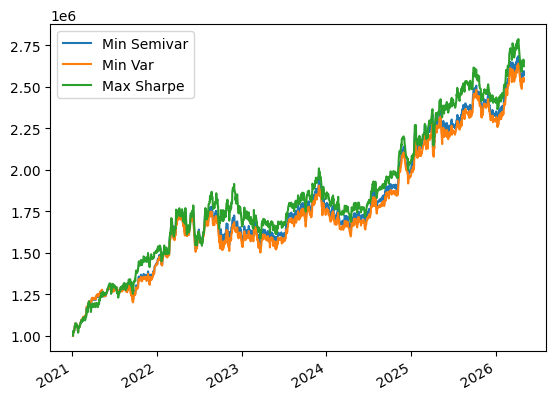

In [101]:
results.evolution.plot()

In [102]:
results.metrics

,Min Semivar,Min Var,Max Sharpe
Rendimiento esperado,0.193332,0.190406,0.199926
Rendimiento realizado,1.569929,1.533596,1.623861
Volatilidad,0.175290,0.173932,0.189944
Ratio de sharpe,0.846207,0.835995,0.815639
Downside risk,0.103344,0.102387,0.111659
Upside risk,0.106060,0.105262,0.115889
Omega,1.026283,1.028074,1.037886
Beta,NaN,NaN,NaN
Alpha de Jensen,NaN,NaN,NaN
Ratio de Treynor,NaN,NaN,NaN
